<a href="https://colab.research.google.com/github/naguibahmed961-art/My-Projects/blob/main/SpeechEmotionRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from IPython.display import Audio
import librosa
import librosa.display as disp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import LSTM, Flatten, Dense, TimeDistributed, Dropout, BatchNormalization,Input
from tensorflow.keras.models import Sequential
from keras.layers import Conv1D
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
import os

path  = "/content/drive/MyDrive/Speech Emotion Recognition"

def load_data(path):
  f_emotion = []
  f_path = []

  folders = os.listdir(path)
  for folder_name in folders: # Renamed 'folder' to 'folder_name' to avoid conflict with parameter name 'folder' if it were used, and for clarity
    current_folder_path = os.path.join(path, folder_name) # Correctly join path and folder_name
    files = os.listdir(current_folder_path)
    for file in files:
      step = file.split(".")[0]
      step = step.split("-")[2]
      f_emotion.append(int(step))
      f_path.append(os.path.join(current_folder_path, file)) # Correctly join current_folder_path and file
  return f_emotion, f_path

In [ ]:
emotions,pathes=load_data(path)

In [ ]:

def get_emotion(number):
  info = {
      1:"neutral",
      2:"calm",
      3:"happy",
      4:"sad",
      5:"angry",
      6:"fearful",
      7:"disgust",
      8:"surprised"}
  return info[number]





In [ ]:
def read_audio(path):
  data, sample_rate = librosa.load(path,duration=2.2,offset=0.6)
  return data, sample_rate

def drow_wave(path, data, sr):
  plt.figure(figsize=(10, 4))
  plt.title('Audio Waveform :: ' + path, size=14)
  plt.xlabel('Time (s)')
  plt.ylabel('Amplitude')
  # Changed keyword from sample_rate to sr
  disp.waveshow(data, sr=sr)

# To fix the NameError, we must load the data first
data, sr = read_audio(pathes[30])


In [ ]:
def add_noise(data,sr):
  noise_amp = 0.035*np.random.uniform()*np.amax(data)
  data = data + noise_amp*np.random.normal(size=data.shape[0])
  return data,sr

def shift(data,sr):
  shift_range = int(5000*np.random.uniform(low=-2,high=3)*1000)
  shifted = np.roll(data,shift_range)
  return shifted,sr

def pitch(data,sr,factor=0.7):
  pitched = librosa.effects.pitch_shift(y=data,sr=sr,n_steps=factor)
  return pitched,sr

def stretch(data,sr,rate=0.8):
  stretched = librosa.effects.time_stretch(y=data,rate=0.8)
  return stretched,sr

### feature Extraction MFCCs:
def feature_extraction(data,sr):
  mfcc = librosa.feature.mfcc(y=data,sr=sr)
  return mfcc

def processing_audio(data,sr,options):
  func = random.choice(options)

  if func == 'standard':
    processed=data
  else:
    processed,_ = func(data,sr)
  return processed



angry
2


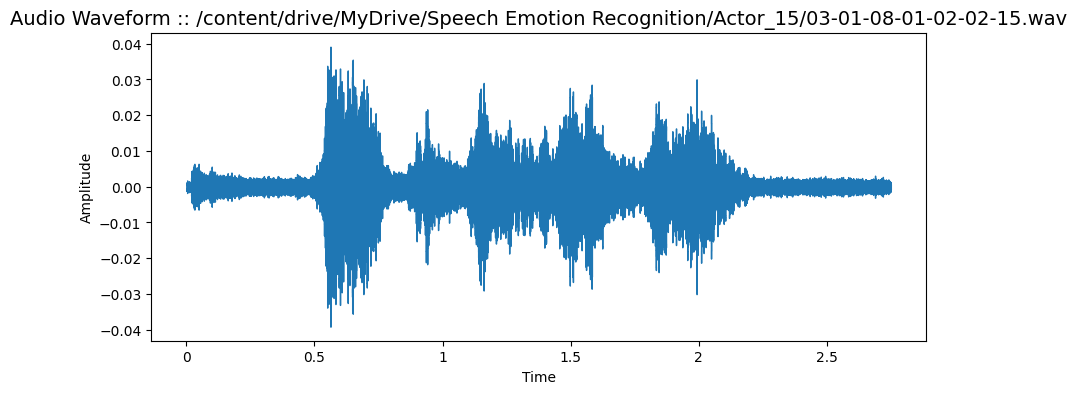

In [ ]:
from numpy.random import f
from librosa.feature import mfcc

def get_features(path):
  data,sr = read_audio(path)
  func = ['standard',add_noise,pitch]
  random.choice(func)

  features=[]

  func1_data = processing_audio(data,sr,func)
  func2_data = processing_audio(func1_data,sr,func)
  feature = feature_extraction(func2_data,sr)

  if feature.shape == (20,95):
    features.append(feature)

  func1_data = processing_audio(data,sr,func)
  func2_data = processing_audio(func1_data,sr,func)
  feature = feature_extraction(func2_data,sr)
  if feature.shape == (20,95):
    features.append(feature)

  func1_data = processing_audio(data,sr,func)
  func2_data = processing_audio(func1_data,sr,func)
  feature = feature_extraction(func2_data,sr)
  if feature.shape == (20,95):
    features.append(feature)

  return features


def display(number):

  data,sample_rate = read_audio(pathes[number])
  print(get_emotion(emotions[30]))
  mfcc_features = feature_extraction(data,sample_rate)
  print(len(mfcc_features.shape))
  data,sample_rate =add_noise(data,sample_rate)
  data,sample_rate = stretch(data,sample_rate)
  data,sample_rate = pitch(data,sample_rate)
  data,sample_rate = shift(data,sample_rate)
  drow_wave(pathes[number],data,sr)

  return data, sample_rate


d, sr = display(70)
Audio(data=d, rate=sr)

In [ ]:
x=[]
y=[]
for index in range(len(pathes)):
  value = get_features(pathes[index])
  if value != []:
    for item in value:
      x.append(item)
      y.append(np.eye(8)[emotions[index]-1])


In [ ]:
from numpy._core.defchararray import encode
encoder = OneHotEncoder()
encoder.fit_transform(np.array([1,2,3,4,5,6,7,8]).reshape(-1,1)).toarray()

array([[1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1.]])

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(np.array(x),np.array(y),test_size=0.2,random_state=11,shuffle=True)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(3456, 20, 95) (864, 20, 95) (3456, 8) (864, 8)


In [ ]:
trainX = np.expand_dims(x_train,axis=3)
trainX = np.expand_dims(trainX,axis=3)
trainX = np.swapaxes(trainX,1,2)

print(trainX.shape)

testX = np.expand_dims(x_test,axis=3)
testX = np.expand_dims(testX,axis=3)
testX = np.swapaxes(testX,1,2)

print(testX.shape)

inputShape = trainX.shape[1:]
print(inputShape)

(3456, 95, 20, 1, 1)
(864, 95, 20, 1, 1)
(95, 20, 1, 1)


In [ ]:
def create_model(inputShape):
    model = Sequential()
    # inputShape should be (95, 20) representing (timesteps, features)
    model.add(Input(shape=inputShape))

    # Conv1D inside TimeDistributed expects (None, 95, 20)
    # It treats 95 as the time dimension and 20 as the spatial/feature dimension
    model.add(TimeDistributed(Dense(32, activation='relu')))

    # Alternatively, if you want spatial convolutions on the 20 MFCCs over 95 time steps:
    # The input shape should be (95, 20, 1) and use Conv1D inside TimeDistributed

    model.add(LSTM(128,return_sequences=True))
    model.add(LSTM(64))
    model.add(Dropout(0.2))

    model.add(Dense(units=64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(units=64, activation='relu'))
    model.add(Dense(units=8, activation='softmax'))

    return model

# Adjusting inputShape to match the expected 3D structure (samples, time, features)
# Based on your previous cell, we reshape to (samples, 95, 20)
model_input_shape = (95, 20)
model = create_model(model_input_shape)
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_7              │ (None, 95, 32)         │           672 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 95, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,352 (552.16 KB)

 Trainable params: 141,352 (552.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
opt = Adam(learning_rate=0.0001)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Squeeze the input data to remove redundant dimensions (1, 1)
# This converts (3456, 95, 20, 1, 1) to (3456, 95, 20)
trainX_fixed = np.squeeze(trainX)
testX_fixed = np.squeeze(testX)

reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, verbose=1, patience=10, min_lr=1e-7)
stop = EarlyStopping(monitor='val_loss', patience=20,restore_best_weights=True,verbose=1)

hist = model.fit(
    trainX_fixed,
    y_train,
    batch_size=32,
    epochs=80,
    validation_data=(testX_fixed, y_test),
    callbacks=[reduce, stop]
)

Epoch 1/80
108/108 ━━━━━━━━━━━━━━━━━━━━ 36s 268ms/step - accuracy: 0.1620 - loss: 2.0719 - val_accuracy: 0.1956 - val_loss: 2.0293 - learning_rate: 1.0000e-04
Epoch 2/80
108/108 ━━━━━━━━━━━━━━━━━━━━ 22s 202ms/step - accuracy: 0.2289 - loss: 2.0029 - val_accuracy: 0.3067 - val_loss: 1.9215 - learning_rate: 1.0000e-04
Epoch 3/80
108/108 ━━━━━━━━━━━━━━━━━━━━ 41s 199ms/step - accuracy: 0.2821 - loss: 1.8873 - val_accuracy: 0.3229 - val_loss: 1.7830 - learning_rate: 1.0000e-04
Epoch 4/80
108/108 ━━━━━━━━━━━━━━━━━━━━ 24s 220ms/step - accuracy: 0.3336 - loss: 1.7660 - val_accuracy: 0.3692 - val_loss: 1.6655 - learning_rate: 1.0000e-04
Epoch 5/80
108/108 ━━━━━━━━━━━━━━━━━━━━ 21s 196ms/step - accuracy: 0.3559 - loss: 1.6917 - val_accuracy: 0.3796 - val_loss: 1.6156 - learning_rate: 1.0000e-04
Epoch 6/80
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 231ms/step - accuracy: 0.3718 - loss: 1.6314 - val_accuracy: 0.3935 - val_loss: 1.5742 - learning_rate: 1.0000e-04
Epoch 7/80
108/108 ━━━━━━━━━━━━━━━━━━━━ 22s 20

In [ ]:
print('the accuracy : ',model.evaluate(trainX_fixed, y_train)[1]*100)


108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.7960 - loss: 0.5724
the accuracy :  79.60069179534912


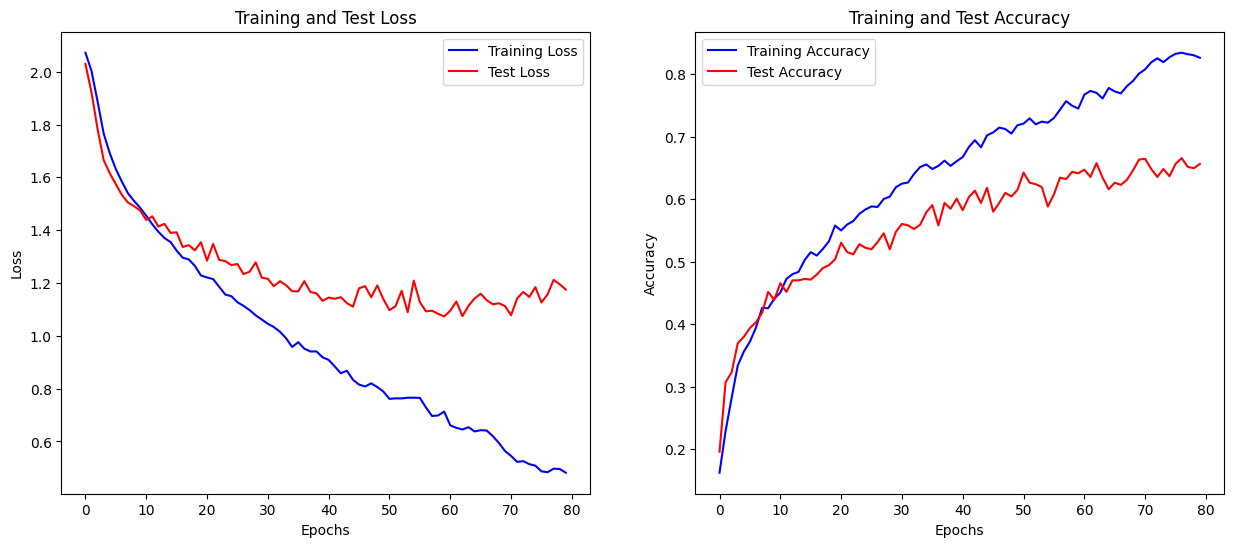

In [ ]:
train_loss = hist.history['loss']
test_loss = hist.history['val_loss']
train_acc = hist.history['accuracy']
test_acc = hist.history['val_accuracy']

epochs = [value for value in range(80)]
fig, ax = plt.subplots(1,2)
fig.set_size_inches(15,6)

ax[0].plot(epochs, train_loss, 'b', label='Training Loss')
ax[0].plot(epochs, test_loss, 'r', label='Test Loss')
ax[0].set_title('Training and Test Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")

ax[1].plot(epochs, train_acc, 'b', label='Training Accuracy')
ax[1].plot(epochs, test_acc, 'r', label='Test Accuracy')
ax[1].set_title('Training and Test Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Accuracy")

plt.show()

In [ ]:
# Save the model first so it exists at the path you want to load
model_path = '/content/drive/MyDrive/Speech Emotion Recognition/model.h5'
model.save(model_path)

# Now you can load it and make predictions
emotion_model = load_model(model_path)
y_pred = emotion_model.predict(testX_fixed)

27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step


In [ ]:
predY = encoder.inverse_transform(y_pred)
testY = encoder.inverse_transform(y_test)

emotion_prediction = [get_emotion(value)for value in predY.flatten()]
emotion_actual = [get_emotion(value)for value in testY.flatten()]

df = pd.DataFrame(columns=['Predicted Emotion', 'Actual Emotion'])
df['Predicted Emotion'] = emotion_prediction
df['Actual Emotion'] = emotion_actual
df.head(10)

,Predicted Emotion,Actual Emotion
0,fearful,sad
1,surprised,surprised
2,disgust,disgust
3,happy,happy
4,neutral,neutral
5,calm,calm
6,calm,calm
7,angry,angry
8,fearful,happy
9,neutral,fearful


<Axes: >

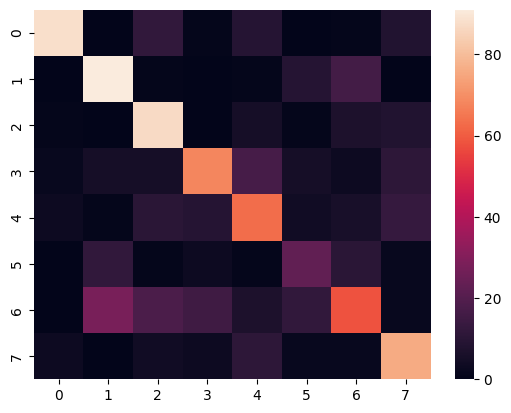

In [ ]:
cm = confusion_matrix(emotion_actual, emotion_prediction)
cmt = pd.DataFrame(cm)
sns.heatmap(cmt)